In [37]:
import pandas as pd
import jieba
import collections
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [38]:
# 解决 Matplotlib 中文显示方块问题
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows用黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

In [39]:
df = pd.read_csv('bilibili_recommend.csv')
df = df.dropna(subset=['title']) 
df['title'] = df['title'].astype(str) 
df = df[df['title'].str.strip() != ''] 
df = df[df['title'].str.lower() != 'nan'] 
print(f"清洗后，共保留 {len(df)} 条有效视频数据。")

清洗后，共保留 181 条有效视频数据。


In [40]:
stop_words = set(['的', '了', '是', '我', '你', '在', '和', '就', '不', '都', '一个', '什么', '怎么', '如何', '为什么', '这', '那', '有', 'nan', '这个', '自己', '同人', '扶持', '计划'])

all_titles = " ".join(df['title'])
words_list = jieba.lcut(all_titles)

filtered_words = [word for word in words_list if word not in stop_words and len(word) > 1]
word_counts = collections.Counter(filtered_words)
top_words = word_counts.most_common(15)
print("排名前15的主题词：")
for word, count in top_words:
    print(f"{word}: {count}次")

排名前15的主题词：
AI: 9次
独家: 7次
游戏: 6次
世界: 6次
中国: 5次
制作: 5次
体验: 5次
日本: 4次
10: 4次
原创: 4次
华为: 4次
不是: 4次
真实: 4次
视频: 4次
全民: 4次


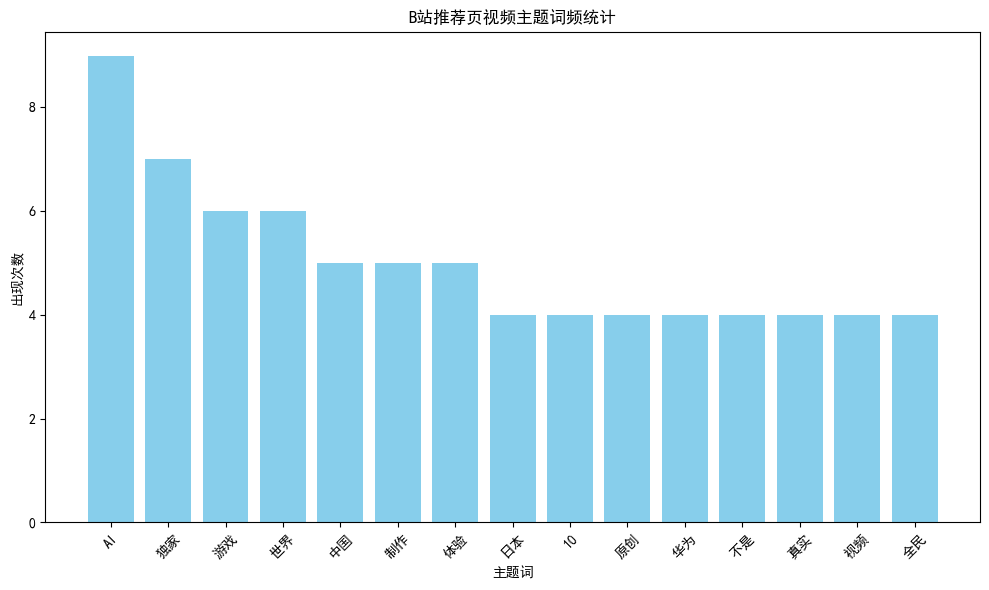

In [41]:
words = [item[0] for item in top_words]
counts = [item[1] for item in top_words]

plt.figure(figsize=(10, 6))
plt.bar(words, counts, color='skyblue')
plt.title('B站推荐页视频主题词频统计')
plt.xlabel('主题词')
plt.ylabel('出现次数')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

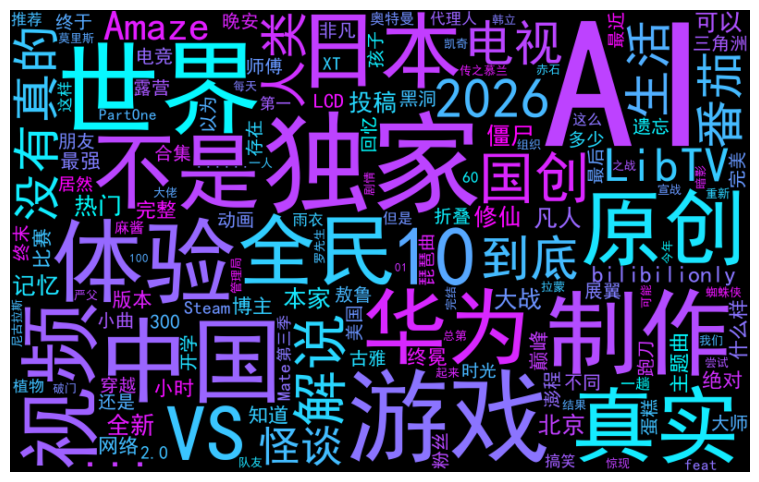

In [42]:
top_word = word_counts.most_common(1)[0][0]
word_counts[top_word] *= 4

wc = WordCloud(
    font_path='C:/Windows/Fonts/simhei.ttf',
    background_color='black',       
    width=800,
    height=500,
    max_words=150,
    colormap='cool',              
    max_font_size=200,              
    min_font_size=10,
    random_state=42,
    contour_width=0                 
).generate_from_frequencies(word_counts)

plt.figure(figsize=(10, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()